# 3D Instance Segmentation Benchmark — Unified Evaluation

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════════════════════════════════════

GT_DIR   = r"/NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/masks"
PRED_DIR = r"/NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results"
RAW_DIR  = r"/NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/images"  # for visual audit

IOU_THRESH = 0.5
MAP_THRESHOLDS = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
EVAL_SUBDIR = "evaluation"
PLOT_DPI = 300
MIN_INSTANCE_VOLUME = 0
EDGE_FRACTION = 0.15
BOUNDARY_RELAX_SLICES = 1  # ±N slices tolerance for boundary relaxation test
OVERLAP_MIN_FRAC = 0.1  # minimum overlap fraction to count as "significant"
BOUNDARY_ERR_FRAC = 0.6  # if >60% of FN pixels are in first/last 20% z-slices → boundary error
N_WORST_EXAMPLES = 3     # number of visual examples per failure mode per model

In [2]:
import os, glob, warnings
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from scipy.ndimage import label as scipy_label
from scipy.optimize import linear_sum_assignment
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon
warnings.filterwarnings("ignore")
print("OK")

OK


## 1 — Data loading

In [3]:
def discover_models(pred_dir):
    models = []
    for name in sorted(os.listdir(pred_dir)):
        d = os.path.join(pred_dir, name)
        if not os.path.isdir(d) or name == EVAL_SUBDIR:
            continue
        if glob.glob(os.path.join(d, '*.tif')) + glob.glob(os.path.join(d, '*.tiff')):
            models.append(name)
    return models

def normalize_filename(f):
    base = os.path.splitext(os.path.basename(f))[0]
    for p in ['pred_','prediction_','seg_']:
        if base.lower().startswith(p):
            base = base[len(p):]; break
    return base.lower()

def match_pred_to_gt(model_dir, gt_dir):
    gt_f = {normalize_filename(f):f for f in sorted(glob.glob(os.path.join(gt_dir,'*.tif'))+glob.glob(os.path.join(gt_dir,'*.tiff')))}
    pr_f = {normalize_filename(f):f for f in sorted(glob.glob(os.path.join(model_dir,'*.tif'))+glob.glob(os.path.join(model_dir,'*.tiff')))}
    pairs = []
    for k,pf in pr_f.items():
        if k in gt_f: pairs.append((gt_f[k], pf))
    return pairs

def load_volume(path):
    v = tifffile.imread(path)
    if v.ndim == 2: v = v[np.newaxis]
    assert v.ndim == 3, f"Expected 3D, got {v.shape}"
    return v.astype(np.int32)

def relabel_connected(vol):
    return vol

models = discover_models(PRED_DIR)
print(f"Models: {models}")
for m in models:
    print(f"  {m}: {len(match_pred_to_gt(os.path.join(PRED_DIR,m), GT_DIR))} vol(s)")

Models: ['cellpose_mice_neurons_oblique_chunked', 'microsam_vit_b_lm_finetuned_mice_oblique', 'microsam_vit_b_lm_pretrained_mice_oblique', 'nnunet_3d_fullres_DEFAULT', 'stardist_mice_neurons_oblique_lightaug_final', 'stardist_mice_neurons_oblique_noaug_final', 'unet3d_mice_neurons_oblique_light_aug', 'unet3d_mice_neurons_oblique_no_aug']
  cellpose_mice_neurons_oblique_chunked: 4 vol(s)
  microsam_vit_b_lm_finetuned_mice_oblique: 4 vol(s)
  microsam_vit_b_lm_pretrained_mice_oblique: 4 vol(s)
  nnunet_3d_fullres_DEFAULT: 4 vol(s)
  stardist_mice_neurons_oblique_lightaug_final: 4 vol(s)
  stardist_mice_neurons_oblique_noaug_final: 4 vol(s)
  unet3d_mice_neurons_oblique_light_aug: 4 vol(s)
  unet3d_mice_neurons_oblique_no_aug: 4 vol(s)


## 2 — Instance matching (Hungarian) & metrics

In [4]:
def iou_matrix(gt, pred):
    gt_ids   = np.unique(gt);   gt_ids   = gt_ids[gt_ids != 0]
    pred_ids = np.unique(pred); pred_ids = pred_ids[pred_ids != 0]
    ng, np_ = len(gt_ids), len(pred_ids)
    if ng == 0 or np_ == 0:
        return (gt_ids, pred_ids,
                np.zeros((ng, np_), dtype=np.float64),
                np.zeros((ng, np_), dtype=np.int64),
                np.zeros(ng, dtype=np.int64),
                np.zeros(np_, dtype=np.int64))
    gt_rm = np.zeros(int(gt.max())+1, dtype=np.int64)
    pr_rm = np.zeros(int(pred.max())+1, dtype=np.int64)
    for i,g in enumerate(gt_ids):   gt_rm[g] = i+1
    for j,p in enumerate(pred_ids): pr_rm[p] = j+1
    np1 = np.int64(np_+1)
    codes = gt_rm[gt.ravel()] * np1 + pr_rm[pred.ravel()]
    tbl = np.bincount(codes, minlength=int((ng+1)*np1)).reshape(ng+1, int(np1))
    ov = tbl[1:,1:].copy()
    gv = tbl[1:,:].sum(1)
    pv = tbl[:,1:].sum(0)
    un = gv[:,None] + pv[None,:] - ov
    iou = np.zeros_like(ov, dtype=np.float64)
    m = un > 0
    iou[m] = ov[m].astype(np.float64) / un[m].astype(np.float64)
    return gt_ids, pred_ids, iou, ov, gv, pv

In [5]:
def hungarian_match(iou_mat, thresh):
    if iou_mat.size == 0:
        return []
    gt_has_overlap = np.any(iou_mat > 0, axis=1)
    pr_has_overlap = np.any(iou_mat > 0, axis=0)
    gt_idx = np.where(gt_has_overlap)[0]
    pr_idx = np.where(pr_has_overlap)[0]
    if len(gt_idx) == 0 or len(pr_idx) == 0:
        return []
    sub = iou_mat[np.ix_(gt_idx, pr_idx)]
    cost = -sub
    row_ind, col_ind = linear_sum_assignment(cost)
    matches = []
    for r, c in zip(row_ind, col_ind):
        iou_val = sub[r, c]
        if iou_val >= thresh:
            matches.append((int(gt_idx[r]), int(pr_idx[c]), float(iou_val)))
    return matches

In [6]:
def obj_metrics_at_thresh(iou_mat, n_gt, n_pred, thresh):
    """Object-level F1, Prec, Rec, mean matched IoU at one IoU threshold."""
    if n_gt == 0 and n_pred == 0:
        return dict(f1=1.,precision=1.,recall=1.,mean_iou=1.,tp=0,fp=0,fn=0)
    if n_gt == 0:
        return dict(f1=0.,precision=0.,recall=0.,mean_iou=0.,tp=0,fp=n_pred,fn=0)
    if n_pred == 0:
        return dict(f1=0.,precision=0.,recall=0.,mean_iou=0.,tp=0,fp=0,fn=n_gt)
    matches = hungarian_match(iou_mat, thresh)
    tp = len(matches)
    fp = n_pred - tp
    fn = n_gt - tp
    pr = tp/(tp+fp) if tp+fp>0 else 0.
    rc = tp/(tp+fn) if tp+fn>0 else 0.
    f1 = 2*pr*rc/(pr+rc) if pr+rc>0 else 0.
    # mean IoU: sum of matched IoUs / n_gt (unmatched GT contribute 0)
    sum_iou = sum(m[2] for m in matches)
    mi = sum_iou / n_gt if n_gt > 0 else 0.
    return dict(f1=f1,precision=pr,recall=rc,mean_iou=mi,tp=tp,fp=fp,fn=fn)

In [7]:
def compute_aji(gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols):
    ng, np_ = len(gt_ids), len(pred_ids)
    if ng==0 and np_==0: return 1.
    if ng==0 or np_==0:  return 0.
    used = set()
    si, su = 0, 0
    for i in range(ng):
        bj, bv = -1, 0.
        for j in range(np_):
            if j in used: continue
            if iou_mat[i,j] > bv: bv=iou_mat[i,j]; bj=j
        if bj>=0 and bv>0:
            inter = int(overlap[i,bj])
            union = int(gt_vols[i])+int(pred_vols[bj])-inter
            si+=inter; su+=union; used.add(bj)
        else:
            su+=int(gt_vols[i])
    for j in range(np_):
        if j not in used: su+=int(pred_vols[j])
    return si/su if su>0 else 0.

In [8]:
def compute_ap_single_thresh(iou_mat, n_gt, n_pred, thresh):
    if n_gt == 0 and n_pred == 0: return 1.
    if n_gt == 0: return 0.
    if n_pred == 0: return 0.
    pred_scores = iou_mat.max(axis=0)
    sorted_j = np.argsort(-pred_scores)
    matched_gt = np.zeros(n_gt, dtype=bool)
    tps = np.zeros(n_pred, dtype=np.float64)
    fps = np.zeros(n_pred, dtype=np.float64)
    for rank, j in enumerate(sorted_j):
        best_i = -1
        best_iou = 0.
        for i in range(n_gt):
            if matched_gt[i]:
                continue
            if iou_mat[i, j] > best_iou:
                best_iou = iou_mat[i, j]
                best_i = i
        if best_i >= 0 and best_iou >= thresh:
            tps[rank] = 1
            matched_gt[best_i] = True
        else:
            fps[rank] = 1
    tp_cum = np.cumsum(tps)
    fp_cum = np.cumsum(fps)
    recalls    = tp_cum / n_gt
    precisions = tp_cum / (tp_cum + fp_cum)
    ap = 0.
    for t in np.linspace(0, 1, 101):
        mask = recalls >= t
        if mask.any():
            ap += precisions[mask].max()
    return ap / 101.

def compute_mAP(iou_mat, n_gt, n_pred):
    return float(np.mean([
        compute_ap_single_thresh(iou_mat, n_gt, n_pred, t)
        for t in MAP_THRESHOLDS
    ]))

In [9]:
def pixel_metrics(gt, pred):
    g, p = (gt>0), (pred>0)
    tp=int(np.sum(g&p)); fp=int(np.sum(~g&p)); fn=int(np.sum(g&~p))
    pr=tp/(tp+fp) if tp+fp>0 else 1.
    rc=tp/(tp+fn) if tp+fn>0 else 1.
    dice=2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 1.
    iou=tp/(tp+fp+fn) if (tp+fp+fn)>0 else 1.
    return dict(pixel_dice=dice, pixel_iou=iou, pixel_prec=pr, pixel_rec=rc)

def evaluate_volume_cached(gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols, gt, pred):
    ng, np_ = len(gt_ids), len(pred_ids)
    matches = hungarian_match(iou_mat, IOU_THRESH)
    tp = len(matches)
    fp = np_ - tp
    fn = ng - tp
    pr = tp/(tp+fp) if tp+fp > 0 else 0.
    rc = tp/(tp+fn) if tp+fn > 0 else 0.
    f1 = 2*pr*rc/(pr+rc) if pr+rc > 0 else 0.
    sum_iou = sum(m[2] for m in matches)
    mi = sum_iou / ng if ng > 0 else 0.
    if ng == 0 and np_ == 0:
        pr, rc, f1, mi = 1., 1., 1., 1.
    aji = compute_aji(gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols)
    mAP = compute_mAP(iou_mat, ng, np_)
    pix = pixel_metrics(gt, pred)
    return {
        'n_gt': ng, 'n_pred': np_,
        'AJI': aji,
        f'Obj_F1@{IOU_THRESH}': f1,
        f'Obj_Prec@{IOU_THRESH}': pr,
        f'Obj_Rec@{IOU_THRESH}': rc,
        f'Obj_IoU@{IOU_THRESH}': mi,
        'mAP_0.5_0.95': mAP,
        'Pixel_Dice': pix['pixel_dice'],
        'Pixel_IoU': pix['pixel_iou'],
        'Pixel_Prec': pix['pixel_prec'],
        'Pixel_Rec': pix['pixel_rec'],
        'TP_obj': tp, 'FP_obj': fp, 'FN_obj': fn,
    }

## 3 — Z-slice analysis

In [10]:
def compute_z_analysis_cached(gt_ids, pred_ids, iou_mat, gt, pred):
    nz = gt.shape[0]
    matches = hungarian_match(iou_mat, IOU_THRESH)
    tp_gt  = set(gt_ids[m[0]] for m in matches)
    fn_gt  = set(gt_ids[i] for i in range(len(gt_ids))
                 if i not in {m[0] for m in matches})
    fp_pr  = set(pred_ids[j] for j in range(len(pred_ids))
                 if j not in {m[1] for m in matches})
    rows = []
    for z in range(nz):
        gz, pz = gt[z], pred[z]
        g, p = gz > 0, pz > 0
        tp_px = int(np.sum(g & p))
        fp_px = int(np.sum(~g & p))
        fn_px = int(np.sum(g & ~p))
        gt_px = int(np.sum(g))
        tot = int(gz.size)
        dice = 2*tp_px/(2*tp_px+fp_px+fn_px) if (2*tp_px+fp_px+fn_px) > 0 else 0.
        iou = tp_px/(tp_px+fp_px+fn_px) if (tp_px+fp_px+fn_px) > 0 else 0.
        gl = set(np.unique(gz)) - {0}
        pl = set(np.unique(pz)) - {0}
        ng_z, np_z = len(gl), len(pl)
        tp_o = len(gl & tp_gt)
        fn_o = len(gl & fn_gt)
        fp_o = len(pl & fp_pr)
        rows.append({
            'z': z, 'GT_objects': ng_z, 'Pred_objects': np_z,
            'TP_objects': tp_o, 'FP_objects': fp_o, 'FN_objects': fn_o,
            'TP_pixels': tp_px, 'FP_pixels': fp_px, 'FN_pixels': fn_px,
            'GT_pixels': gt_px, 'total_pixels': tot,
            'Dice': dice, 'IoU': iou,
            'FN_object_rate': fn_o/ng_z if ng_z > 0 else 0.,
            'FP_object_rate': fp_o/np_z if np_z > 0 else 0.,
            'FN_pixel_ratio': fn_px/gt_px if gt_px > 0 else 0.,
            'FP_pixel_ratio': fp_px/tot if tot > 0 else 0.,
        })
    return pd.DataFrame(rows)

## 4 — Main loop

In [11]:
all_vol = []
all_z = []
vol_cache = {}
iou_cache = {}

models = discover_models(PRED_DIR)
print(f"Models: {models}\n")

for mn in models:
    md = os.path.join(PRED_DIR, mn)
    ed = os.path.join(md, EVAL_SUBDIR)
    os.makedirs(ed, exist_ok=True)
    pairs = match_pred_to_gt(md, GT_DIR)
    if not pairs: print(f"[{mn}] skip\n"); continue
    print(f"[{mn}] {len(pairs)} vol(s)")
    mv, mz = [], []
    for gp, pp in pairs:
        vn = os.path.splitext(os.path.basename(gp))[0]
        print(f"  {vn}", end=" ", flush=True)
        try:
            gv = relabel_connected(load_volume(gp))
            pv = relabel_connected(load_volume(pp))
        except Exception as e: print(f"ERR:{e}"); continue
        if gv.shape != pv.shape: print("SHAPE!"); continue

        gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols = iou_matrix(gv, pv)
        iou_cache[(mn, vn)] = (gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols)

        m = evaluate_volume_cached(gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols, gv, pv)
        m['model'], m['volume'] = mn, vn
        mv.append(m)

        zdf = compute_z_analysis_cached(gt_ids, pred_ids, iou_mat, gv, pv)
        zdf['model'], zdf['volume'] = mn, vn
        mz.append(zdf)

        vol_cache[(mn, vn)] = (gv, pv)
        print(f"AJI={m['AJI']:.4f} F1={m[f'Obj_F1@{IOU_THRESH}']:.4f} Dice={m['Pixel_Dice']:.4f}")
    if mv: pd.DataFrame(mv).to_csv(os.path.join(ed,'per_volume_metrics.csv'),index=False)
    if mz: pd.concat(mz,ignore_index=True).to_csv(os.path.join(ed,'z_analysis.csv'),index=False)
    all_vol.extend(mv); all_z.extend(mz)
    print()

df_vol = pd.DataFrame(all_vol)
df_z   = pd.concat(all_z, ignore_index=True) if all_z else pd.DataFrame()
print(f"Done: {len(df_vol)} volumes, {len(models)} models")

Models: ['cellpose_mice_neurons_oblique_chunked', 'microsam_vit_b_lm_finetuned_mice_oblique', 'microsam_vit_b_lm_pretrained_mice_oblique', 'nnunet_3d_fullres_DEFAULT', 'stardist_mice_neurons_oblique_lightaug_final', 'stardist_mice_neurons_oblique_noaug_final', 'unet3d_mice_neurons_oblique_light_aug', 'unet3d_mice_neurons_oblique_no_aug']

[cellpose_mice_neurons_oblique_chunked] 4 vol(s)
  20260209_161350 AJI=0.2144 F1=0.0571 Dice=0.3990
  mouse_obl_14 AJI=0.3407 F1=0.2342 Dice=0.5769
  mouse_obl_15 AJI=0.3708 F1=0.2381 Dice=0.6097
  mouse_obl_6 AJI=0.4863 F1=0.4231 Dice=0.6668

[microsam_vit_b_lm_finetuned_mice_oblique] 4 vol(s)
  20260209_161350 AJI=0.3298 F1=0.2540 Dice=0.5229
  mouse_obl_14 AJI=0.3642 F1=0.3721 Dice=0.6302
  mouse_obl_15 AJI=0.3348 F1=0.3667 Dice=0.6038
  mouse_obl_6 AJI=0.4306 F1=0.6047 Dice=0.6585

[microsam_vit_b_lm_pretrained_mice_oblique] 4 vol(s)
  20260209_161350 AJI=0.1684 F1=0.0345 Dice=0.3235
  mouse_obl_14 AJI=0.2103 F1=0.0217 Dice=0.4247
  mouse_obl_15 A

## 5 — Summary

In [12]:
mc = [c for c in df_vol.columns if c not in ('model','volume','n_gt','n_pred','TP_obj','FP_obj','FN_obj')]
sr = []
for mn, g in df_vol.groupby('model'):
    r = {'model':mn, 'n':len(g)}
    for c in mc:
        v = g[c].values*100
        r[f'{c}_fmt'] = f"{np.mean(v):.2f} ± {np.std(v):.2f}"
    sr.append(r)
df_sum = pd.DataFrame(sr)

ced = os.path.join(PRED_DIR, EVAL_SUBDIR)
os.makedirs(ced, exist_ok=True)
df_sum.to_csv(os.path.join(ced,'metrics_summary.csv'),index=False)
df_vol.to_csv(os.path.join(ced,'per_volume_metrics.csv'),index=False)
if not df_z.empty: df_z.to_csv(os.path.join(ced,'z_analysis.csv'),index=False)

pcols = ['AJI',f'Obj_F1@{IOU_THRESH}',f'Obj_Prec@{IOU_THRESH}',
         f'Obj_Rec@{IOU_THRESH}',f'Obj_IoU@{IOU_THRESH}','mAP_0.5_0.95',
         'Pixel_Dice','Pixel_IoU','Pixel_Prec','Pixel_Rec']
for mn, g in df_vol.groupby('model'):
    print(f"\n{mn} (n={len(g)}):")
    for c in pcols:
        v = g[c].values*100
        print(f"  {c:25s}  {np.mean(v):6.2f} ± {np.std(v):5.2f}")


cellpose_mice_neurons_oblique_chunked (n=4):
  AJI                         35.30 ±  9.68
  Obj_F1@0.5                  23.81 ± 12.94
  Obj_Prec@0.5                18.50 ± 10.01
  Obj_Rec@0.5                 33.83 ± 18.38
  Obj_IoU@0.5                 20.71 ± 11.31
  mAP_0.5_0.95                 9.26 ±  5.03
  Pixel_Dice                  56.31 ± 10.01
  Pixel_IoU                   39.83 ±  9.26
  Pixel_Prec                  82.88 ±  5.68
  Pixel_Rec                   44.12 ± 11.21

microsam_vit_b_lm_finetuned_mice_oblique (n=4):
  AJI                         36.48 ±  4.02
  Obj_F1@0.5                  39.93 ± 12.76
  Obj_Prec@0.5                36.58 ± 10.78
  Obj_Rec@0.5                 44.13 ± 15.38
  Obj_IoU@0.5                 26.44 ±  9.36
  mAP_0.5_0.95                11.26 ±  4.34
  Pixel_Dice                  60.39 ±  5.06
  Pixel_IoU                   43.44 ±  5.08
  Pixel_Prec                  55.68 ±  2.91
  Pixel_Rec                   67.50 ± 11.45

microsam_vit_b_lm_pretra

## 6 — Plot setup

In [14]:
plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'cm', 'font.size':8,
    'axes.labelsize':9, 'axes.titlesize':9,
    'xtick.labelsize':7, 'ytick.labelsize':7, 'legend.fontsize':6.5,
    'axes.linewidth':0.5,
    'xtick.major.width':0.4, 'ytick.major.width':0.4,
    'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.major.pad':2, 'ytick.major.pad':2,
    'lines.linewidth':1.0,
    'savefig.dpi':PLOT_DPI, 'savefig.bbox':'tight', 'savefig.pad_inches':0.02,
})

# Wong 2011 colorblind-safe
COL = ['#0072B2','#D55E00','#009E73','#CC79A7','#E69F00','#56B4E9','#000000','#F0E442']
LST = ['-','--','-.',':',(0,(3,1,1,1)),(0,(5,1)),'-','--']

def _s(i): return dict(color=COL[i%len(COL)], linestyle=LST[i%len(LST)])

def _agg(dz, m, c):
    d = dz[dz['model']==m]
    if d.empty: return None, None
    g = d.groupby('z')[c].mean().reset_index()
    return g['z'].values, g[c].values

def _leg(fig, ax):
    """Compact legend above plot, wrapped to fit figure width."""
    h, l = ax.get_legend_handles_labels()
    if not h: return
    # auto ncol: fit within figure width
    nc = min(len(h), 3)
    fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 1.0),
               ncol=nc, frameon=False, handlelength=2.0,
               columnspacing=0.8, handletextpad=0.4, fontsize=6)

def _cl(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print('Style OK')

Style OK


## 7 — Z-slice plots

In [15]:
def plot_h(dz, col, yl, path, ml, ylim=None):
    if dz.empty: return
    fig, ax = plt.subplots(figsize=(3.4, 2.2))
    for i,m in enumerate(ml):
        z,v = _agg(dz,m,col)
        if z is None: continue
        ax.plot(z,v,label=m,**_s(i))
    ax.set_xlabel('Z slice'); ax.set_ylabel(yl)
    if ylim: ax.set_ylim(ylim)
    _cl(ax); _leg(fig,ax)
    fig.savefig(path,dpi=PLOT_DPI,bbox_inches='tight')
    plt.show(); plt.close(fig)

def plot_v(dz, col, xl, path, ml, xlim=None):
    if dz.empty: return
    fig, ax = plt.subplots(figsize=(2.6, 3.8))
    for i,m in enumerate(ml):
        z,v = _agg(dz,m,col)
        if z is None: continue
        ax.plot(v,z,label=m,**_s(i))
    ax.set_xlabel(xl); ax.set_ylabel('Z slice (depth)')
    ax.invert_yaxis()
    if xlim: ax.set_xlim(xlim)
    _cl(ax); _leg(fig,ax)
    fig.savefig(path,dpi=PLOT_DPI,bbox_inches='tight')
    plt.show(); plt.close(fig)

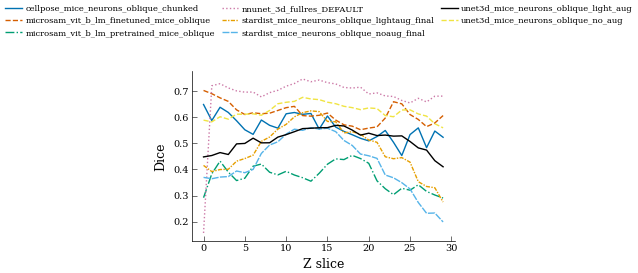

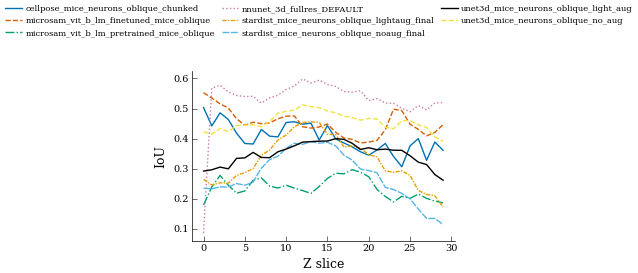

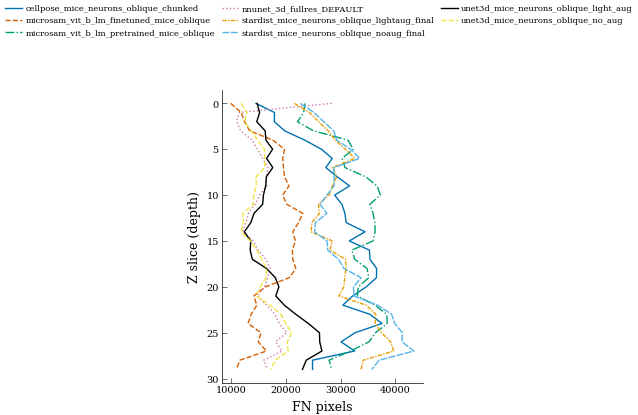

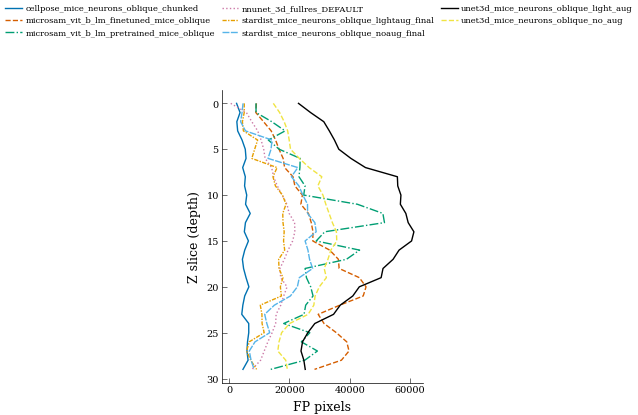

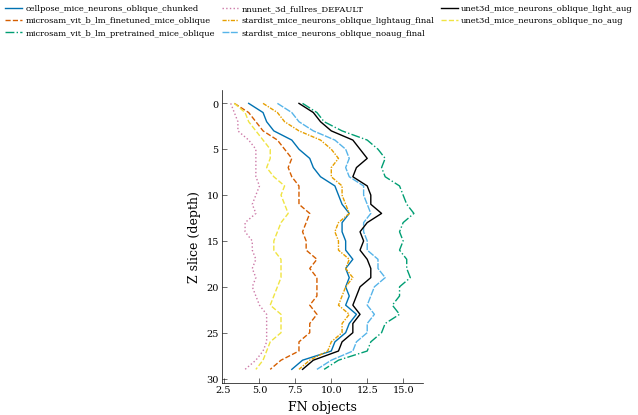

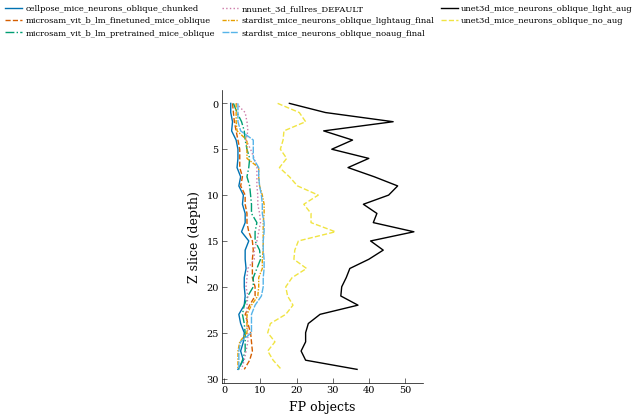

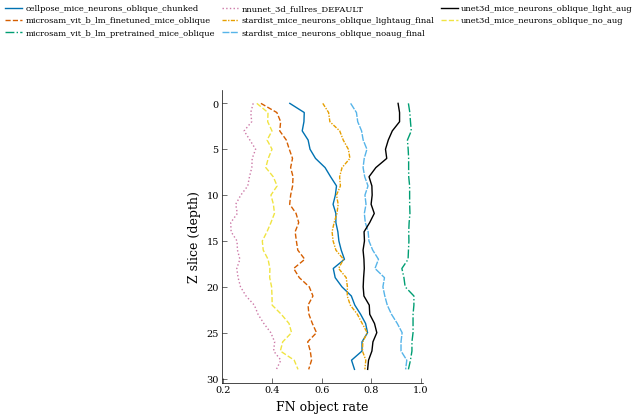

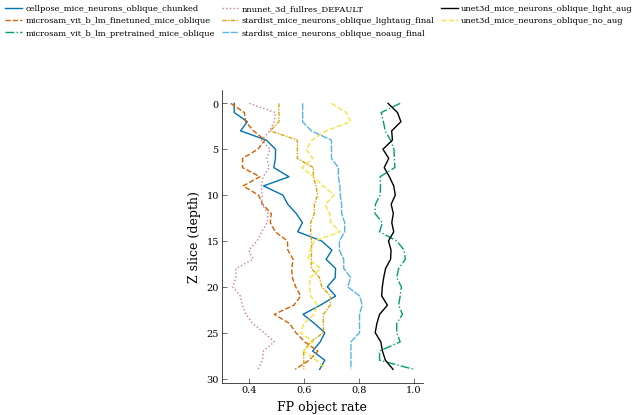

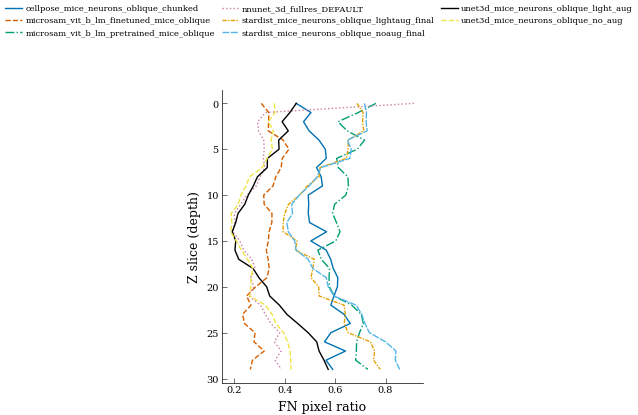

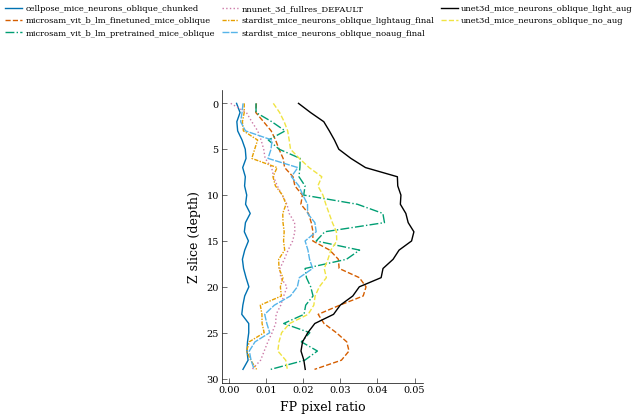

Saved 10 plots to /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/plots


In [16]:
pdir = os.path.join(ced, 'plots')
os.makedirs(pdir, exist_ok=True)
ms = sorted(df_z['model'].unique()) if not df_z.empty else []

h_sp = [('Dice','Dice','dice_vs_z.png', None),
        ('IoU','IoU','iou_vs_z.png', None)]

v_sp = [
    ('FN_pixels','FN pixels','fn_pixels_vs_z.png',None),
    ('FP_pixels','FP pixels','fp_pixels_vs_z.png',None),
    ('FN_objects','FN objects','fn_objects_vs_z.png',None),
    ('FP_objects','FP objects','fp_objects_vs_z.png',None),
    ('FN_object_rate','FN object rate','fn_object_rate_vs_z.png',None),
    ('FP_object_rate','FP object rate','fp_object_rate_vs_z.png',None),
    ('FN_pixel_ratio','FN pixel ratio','fn_pixel_ratio_vs_z.png',None),
    ('FP_pixel_ratio','FP pixel ratio','fp_pixel_ratio_vs_z.png',None),
]

for c,yl,fn,ylim in h_sp: plot_h(df_z,c,yl,os.path.join(pdir,fn),ms,ylim)
for c,xl,fn,xlim in v_sp: plot_v(df_z,c,xl,os.path.join(pdir,fn),ms,xlim)

print(f"Saved {len(h_sp)+len(v_sp)} plots to {pdir}")

## 8 — Per-model plots

In [17]:
for mn in ms:
    mep = os.path.join(PRED_DIR, mn, EVAL_SUBDIR, 'plots')
    os.makedirs(mep, exist_ok=True)
    mdf = df_z[df_z['model']==mn]
    if mdf.empty: continue
    vols = sorted(mdf['volume'].unique())
    for c,yl,fn,ylim in h_sp:
        fig,ax = plt.subplots(figsize=(3.4,2.2))
        for vi,vn in enumerate(vols):
            vd = mdf[mdf['volume']==vn]
            ax.plot(vd['z'].values, vd[c].values, label=vn, **_s(vi))
        ax.set_xlabel('Z slice'); ax.set_ylabel(yl)
        if ylim: ax.set_ylim(ylim)
        _cl(ax); _leg(fig,ax)
        fig.savefig(os.path.join(mep,fn),dpi=PLOT_DPI,bbox_inches='tight'); plt.close(fig)
    for c,xl,fn,xlim in v_sp:
        fig,ax = plt.subplots(figsize=(2.6,3.8))
        for vi,vn in enumerate(vols):
            vd = mdf[mdf['volume']==vn]
            ax.plot(vd[c].values, vd['z'].values, label=vn, **_s(vi))
        ax.set_xlabel(xl); ax.set_ylabel('Z slice (depth)'); ax.invert_yaxis()
        if xlim: ax.set_xlim(xlim)
        _cl(ax); _leg(fig,ax)
        fig.savefig(os.path.join(mep,fn),dpi=PLOT_DPI,bbox_inches='tight'); plt.close(fig)
    print(f"{mn}: {len(h_sp)+len(v_sp)} plots")

cellpose_mice_neurons_oblique_chunked: 10 plots
microsam_vit_b_lm_finetuned_mice_oblique: 10 plots
microsam_vit_b_lm_pretrained_mice_oblique: 10 plots
nnunet_3d_fullres_DEFAULT: 10 plots
stardist_mice_neurons_oblique_lightaug_final: 10 plots
stardist_mice_neurons_oblique_noaug_final: 10 plots
unet3d_mice_neurons_oblique_light_aug: 10 plots
unet3d_mice_neurons_oblique_no_aug: 10 plots


---
## 9 — Hypothesis: edge annotation quality

### 9a. Mann-Whitney U (edge vs interior slices)
### 9b. Spearman ρ (depth trend)
### 9c. Boundary relaxation test
### 9d. Z-relative within-object error analysis
### 9e. Visual audit: FP at edges

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  9a. Mann-Whitney U: edge vs interior
# ══════════════════════════════════════════════════════════════════════════════

def classify_zone(z, nz, ef):
    b = max(1, int(np.ceil(nz*ef)))
    return 'edge' if (z < b or z >= nz-b) else 'interior'

zones = []
for (mn,vn), gdf in df_z.groupby(['model','volume']):
    nz = len(gdf)
    for _,r in gdf.iterrows():
        zones.append(classify_zone(int(r['z']), nz, EDGE_FRACTION))
df_zz = df_z.copy(); df_zz['zone'] = zones

tm = ['FN_objects','FP_objects','FN_object_rate','FP_object_rate',
      'FN_pixels','FP_pixels','FN_pixel_ratio','FP_pixel_ratio','Dice']

mw_rows = []
for mn in ms:
    md = df_zz[df_zz['model']==mn]
    ed_z, ind = md[md['zone']=='edge'], md[md['zone']=='interior']
    for met in tm:
        ev, iv = ed_z[met].dropna().values, ind[met].dropna().values
        if len(ev)<2 or len(iv)<2:
            mw_rows.append(dict(model=mn,metric=met,edge=np.nan,interior=np.nan,p=np.nan,sig='')); continue
        alt = 'less' if met=='Dice' else 'greater'
        U,p = mannwhitneyu(ev, iv, alternative=alt)
        sig = '***' if p<.001 else ('**' if p<.01 else ('*' if p<.05 else ''))
        mw_rows.append(dict(model=mn,metric=met,edge=np.mean(ev),interior=np.mean(iv),U=U,p=p,sig=sig))

df_mw = pd.DataFrame(mw_rows)
df_mw.to_csv(os.path.join(ced,'edge_vs_interior_mannwhitney.csv'),index=False)

print(f"Edge fraction: {EDGE_FRACTION:.0%}")
print("Mann-Whitney U: edge vs interior (* p<.05 ** p<.01 *** p<.001)\n")
for mn in ms:
    s = df_mw[df_mw['model']==mn]
    print(f"{mn}:")
    for _,r in s.iterrows():
        e,i,p = r['edge'],r['interior'],r['p']
        ps = f"{p:.1e}" if (not np.isnan(p) and p<.001) else (f"{p:.4f}" if not np.isnan(p) else 'N/A')
        print(f"  {r['metric']:20s} edge={e:.4f} int={i:.4f} p={ps} {r['sig']}")
    print()

Edge fraction: 15%
Mann-Whitney U: edge vs interior (* p<.05 ** p<.01 *** p<.001)

cellpose_mice_neurons_oblique_chunked:
  FN_objects           edge=7.4750 int=10.5250 p=0.9998 
  FP_objects           edge=3.5250 int=5.0500 p=0.9999 
  FN_object_rate       edge=0.6357 int=0.6662 p=0.7169 
  FP_object_rate       edge=0.5217 int=0.6028 p=0.9751 
  FN_pixels            edge=23840.0500 int=32196.8125 p=0.9992 
  FP_pixels            edge=4518.3000 int=5402.9625 p=0.9453 
  FN_pixel_ratio       edge=0.5393 int=0.5614 p=0.6547 
  FP_pixel_ratio       edge=0.0037 int=0.0044 p=0.9453 
  Dice                 edge=0.5730 int=0.5564 p=0.6849 

microsam_vit_b_lm_finetuned_mice_oblique:
  FN_objects           edge=6.0000 int=8.1625 p=0.9992 
  FP_objects           edge=4.9500 int=6.4125 p=0.9938 
  FN_object_rate       edge=0.4875 int=0.5064 p=0.6246 
  FP_object_rate       edge=0.4989 int=0.4927 p=0.4501 
  FN_pixels            edge=13434.3000 int=19166.6500 p=0.9836 
  FP_pixels            edge=

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  9b. Spearman ρ: depth vs error
# ══════════════════════════════════════════════════════════════════════════════

cm = ['FN_pixels','FP_pixels','FN_objects','FP_objects',
      'FN_object_rate','FP_object_rate','FN_pixel_ratio','FP_pixel_ratio','Dice','IoU']

cr = []
for mn in ms:
    md = df_z[df_z['model']==mn]
    if md.empty: continue
    for met in cm:
        zp, mp = md['z'].values, md[met].values
        v = ~np.isnan(mp)
        if v.sum()>=3 and np.std(mp[v])>1e-12:
            rho,p = spearmanr(zp[v],mp[v])
        else:
            rho,p = np.nan,np.nan
        sig = '***' if (not np.isnan(p) and p<.001) else ('**' if (not np.isnan(p) and p<.01) else ('*' if (not np.isnan(p) and p<.05) else ''))
        cr.append(dict(model=mn,metric=met,rho=rho,p=p,sig=sig))

df_cr = pd.DataFrame(cr)
df_cr.to_csv(os.path.join(ced,'depth_correlation_spearman.csv'),index=False)

print("Spearman ρ (pooled): positive = increases with depth\n")
for mn in ms:
    s = df_cr[df_cr['model']==mn]
    print(f"{mn}:")
    for _,r in s.iterrows():
        rs = f"{r['rho']:+.3f}" if not np.isnan(r['rho']) else 'N/A'
        ps = f"{r['p']:.1e}" if (not np.isnan(r['p']) and r['p']<.001) else (f"{r['p']:.4f}" if not np.isnan(r['p']) else 'N/A')
        print(f"  {r['metric']:20s} ρ={rs} p={ps} {r['sig']}")
    print()

Spearman ρ (pooled): positive = increases with depth

cellpose_mice_neurons_oblique_chunked:
  FN_pixels            ρ=+0.261 p=0.0040 **
  FP_pixels            ρ=+0.140 p=0.1283 
  FN_objects           ρ=+0.294 p=0.0011 **
  FP_objects           ρ=+0.354 p=7.2e-05 ***
  FN_object_rate       ρ=+0.379 p=1.9e-05 ***
  FP_object_rate       ρ=+0.384 p=1.5e-05 ***
  FN_pixel_ratio       ρ=+0.244 p=0.0071 **
  FP_pixel_ratio       ρ=+0.140 p=0.1283 
  Dice                 ρ=-0.245 p=0.0070 **
  IoU                  ρ=-0.245 p=0.0070 **

microsam_vit_b_lm_finetuned_mice_oblique:
  FN_pixels            ρ=-0.062 p=0.5003 
  FP_pixels            ρ=+0.578 p=5.0e-12 ***
  FN_objects           ρ=+0.222 p=0.0146 *
  FP_objects           ρ=+0.484 p=2.1e-08 ***
  FN_object_rate       ρ=+0.271 p=0.0027 **
  FP_object_rate       ρ=+0.437 p=6.1e-07 ***
  FN_pixel_ratio       ρ=-0.253 p=0.0053 **
  FP_pixel_ratio       ρ=+0.578 p=5.0e-12 ***
  Dice                 ρ=-0.221 p=0.0152 *
  IoU                 

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#  9c. Boundary relaxation test
#
#  For each volume, compute metrics twice:
#    STRICT: original GT
#    RELAXED: expand GT foreground mask by ±BOUNDARY_RELAX_SLICES in Z,
#             so FPs at the very top/bottom of GT extent are forgiven.
#  If Obj_F1 / Dice increase under relaxation → evidence of GT boundary noise.
# ══════════════════════════════════════════════════════════════════════════════

from scipy.ndimage import binary_dilation

def relax_gt_boundary(gt, n_slices=1):
    fg = (gt > 0).astype(np.uint8)
    struct = np.zeros((2*n_slices+1, 1, 1), dtype=bool)
    struct[:, 0, 0] = True
    dilated = binary_dilation(fg, structure=struct, iterations=1)
    return dilated.astype(bool)

def pixel_metrics_relaxed(gt, pred, relaxed_fg):
    gt_fg = gt > 0
    pred_fg = pred > 0
    tp = int(np.sum(gt_fg & pred_fg))
    fp_strict = int(np.sum(~gt_fg & pred_fg))
    fp_forgiven = int(np.sum(~gt_fg & pred_fg & relaxed_fg))
    fp = fp_strict - fp_forgiven
    fn = int(np.sum(gt_fg & ~pred_fg))
    pr = tp/(tp+fp) if tp+fp>0 else 1.
    rc = tp/(tp+fn) if tp+fn>0 else 1.
    dice = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 1.
    return dict(pixel_dice_relaxed=dice, pixel_prec_relaxed=pr, pixel_rec_relaxed=rc)

relax_rows = []
for (mn, vn), (gv, pv) in vol_cache.items():
    gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols = iou_cache[(mn, vn)]
    strict = evaluate_volume_cached(gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols, gv, pv)
    relaxed_fg = relax_gt_boundary(gv, BOUNDARY_RELAX_SLICES)
    pix_relax = pixel_metrics_relaxed(gv, pv, relaxed_fg)
    relax_rows.append({
        'model': mn, 'volume': vn,
        'Pixel_Dice_strict': strict['Pixel_Dice'],
        'Pixel_Dice_relaxed': pix_relax['pixel_dice_relaxed'],
        'Pixel_Prec_strict': strict['Pixel_Prec'],
        'Pixel_Prec_relaxed': pix_relax['pixel_prec_relaxed'],
        'Obj_F1_strict': strict[f'Obj_F1@{IOU_THRESH}'],
    })

df_relax = pd.DataFrame(relax_rows)
df_relax['Dice_delta'] = df_relax['Pixel_Dice_relaxed'] - df_relax['Pixel_Dice_strict']
df_relax['Prec_delta'] = df_relax['Pixel_Prec_relaxed'] - df_relax['Pixel_Prec_strict']
df_relax.to_csv(os.path.join(ced, 'boundary_relaxation_test.csv'), index=False)

print(f"Boundary relaxation: ±{BOUNDARY_RELAX_SLICES} slice(s)")
print("Positive delta = metric improves with relaxation = evidence of GT boundary noise\n")
for mn in ms:
    s = df_relax[df_relax['model']==mn]
    if s.empty: continue
    dd = s['Dice_delta'].values * 100
    dp = s['Prec_delta'].values * 100
    print(f"{mn}:")
    print(f"  Dice  strict={s['Pixel_Dice_strict'].mean()*100:.2f}  "
          f"relaxed={s['Pixel_Dice_relaxed'].mean()*100:.2f}  "
          f"Δ={np.mean(dd):+.2f} ± {np.std(dd):.2f}")
    print(f"  Prec  strict={s['Pixel_Prec_strict'].mean()*100:.2f}  "
          f"relaxed={s['Pixel_Prec_relaxed'].mean()*100:.2f}  "
          f"Δ={np.mean(dp):+.2f} ± {np.std(dp):.2f}")

Boundary relaxation: ±1 slice(s)
Positive delta = metric improves with relaxation = evidence of GT boundary noise

cellpose_mice_neurons_oblique_chunked:
  Dice  strict=56.31  relaxed=57.34  Δ=+1.04 ± 0.40
  Prec  strict=82.88  relaxed=87.12  Δ=+4.25 ± 0.47
microsam_vit_b_lm_finetuned_mice_oblique:
  Dice  strict=60.39  relaxed=63.02  Δ=+2.64 ± 0.58
  Prec  strict=55.68  relaxed=60.25  Δ=+4.57 ± 0.54
microsam_vit_b_lm_pretrained_mice_oblique:
  Dice  strict=38.70  relaxed=39.85  Δ=+1.15 ± 0.27
  Prec  strict=45.06  relaxed=48.29  Δ=+3.23 ± 1.00
nnunet_3d_fullres_DEFAULT:
  Dice  strict=70.04  relaxed=72.77  Δ=+2.73 ± 0.62
  Prec  strict=72.50  relaxed=78.35  Δ=+5.85 ± 0.59
stardist_mice_neurons_oblique_lightaug_final:
  Dice  strict=50.53  relaxed=52.28  Δ=+1.75 ± 0.70
  Prec  strict=63.44  relaxed=68.92  Δ=+5.49 ± 0.74
stardist_mice_neurons_oblique_noaug_final:
  Dice  strict=45.49  relaxed=47.07  Δ=+1.58 ± 0.33
  Prec  strict=54.61  relaxed=59.35  Δ=+4.74 ± 0.98
unet3d_mice_neurons_o

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  9d. Z-relative within-object error analysis (KEY TEST)
#
#  For each GT object:
#    - Find z_start, z_end (first/last slice where it appears)
#    - Compute relative position of each slice: (z - z_start) / (z_end - z_start)
#    - If matched to a pred object: compute per-slice Dice for this pair
#    - If unmatched (FN): all slices are errors (Dice=0)
#  Aggregate into 3 zones: START (0-0.2), MIDDLE (0.2-0.8), END (0.8-1.0)
#  If errors ↑ at START and END → annotation boundary problem confirmed.
# ══════════════════════════════════════════════════════════════════════════════

def compute_within_object_z_profile_cached(gt_ids, pred_ids, iou_mat, gt, pred):
    ng = len(gt_ids)
    if ng == 0:
        return []
    matches = hungarian_match(iou_mat, IOU_THRESH)
    match_map = {m[0]: m[1] for m in matches}
    rows = []
    for gi in range(ng):
        gid = gt_ids[gi]
        z_present = np.where(np.any(gt == gid, axis=(1,2)))[0]
        if len(z_present) == 0:
            continue
        z_start = z_present[0]
        z_end   = z_present[-1]
        z_span  = z_end - z_start
        has_match = gi in match_map
        if has_match:
            pid = pred_ids[match_map[gi]]
        for z in z_present:
            z_rel = (z - z_start) / z_span if z_span > 0 else 0.5
            gt_mask_z = (gt[z] == gid)
            gt_area = int(np.sum(gt_mask_z))
            if has_match:
                pred_mask_z = (pred[z] == pid)
                inter = int(np.sum(gt_mask_z & pred_mask_z))
                pred_area = int(np.sum(pred_mask_z))
                dice_z = 2*inter / (gt_area + pred_area) if (gt_area+pred_area) > 0 else 0.
            else:
                dice_z = 0.
                inter = 0
            if z_rel <= 0.2:
                zone = 'start'
            elif z_rel >= 0.8:
                zone = 'end'
            else:
                zone = 'middle'
            rows.append({
                'gt_id': int(gid), 'z': z, 'z_rel': z_rel,
                'zone': zone, 'matched': has_match,
                'gt_area': gt_area, 'overlap': inter,
                'slice_dice': dice_z,
            })
    return rows

print("Computing within-object Z profiles...")
obj_z_rows = []
for (mn, vn), (gv, pv) in vol_cache.items():
    print(f"  {mn}/{vn}", end=" ", flush=True)
    gt_ids, pred_ids, iou_mat, _, _, _ = iou_cache[(mn, vn)]
    rows = compute_within_object_z_profile_cached(gt_ids, pred_ids, iou_mat, gv, pv)
    for r in rows:
        r['model'] = mn
        r['volume'] = vn
    obj_z_rows.extend(rows)
    print(f"({len(rows)} entries)")

df_obj_z = pd.DataFrame(obj_z_rows)
df_obj_z.to_csv(os.path.join(ced, 'within_object_z_profile.csv'), index=False)
print(f"\nTotal entries: {len(df_obj_z)}")

Computing within-object Z profiles...
  cellpose_mice_neurons_oblique_chunked/20260209_161350 (474 entries)
  cellpose_mice_neurons_oblique_chunked/mouse_obl_14 (515 entries)
  cellpose_mice_neurons_oblique_chunked/mouse_obl_15 (380 entries)
  cellpose_mice_neurons_oblique_chunked/mouse_obl_6 (305 entries)
  microsam_vit_b_lm_finetuned_mice_oblique/20260209_161350 (474 entries)
  microsam_vit_b_lm_finetuned_mice_oblique/mouse_obl_14 (515 entries)
  microsam_vit_b_lm_finetuned_mice_oblique/mouse_obl_15 (380 entries)
  microsam_vit_b_lm_finetuned_mice_oblique/mouse_obl_6 (305 entries)
  microsam_vit_b_lm_pretrained_mice_oblique/20260209_161350 (474 entries)
  microsam_vit_b_lm_pretrained_mice_oblique/mouse_obl_14 (515 entries)
  microsam_vit_b_lm_pretrained_mice_oblique/mouse_obl_15 (380 entries)
  microsam_vit_b_lm_pretrained_mice_oblique/mouse_obl_6 (305 entries)
  nnunet_3d_fullres_DEFAULT/20260209_161350 (474 entries)
  nnunet_3d_fullres_DEFAULT/mouse_obl_14 (515 entries)
  nnunet_3d

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  9d continued: aggregate and test
# ══════════════════════════════════════════════════════════════════════════════

if not df_obj_z.empty:
    print("Within-object Z-relative analysis: per-slice Dice at start/middle/end\n")
    print("zone  = start (z_rel <= 0.2), middle (0.2-0.8), end (z_rel >= 0.8)")
    print("If start/end have LOWER Dice → annotation quality drops at object boundaries\n")

    zone_test_rows = []
    for mn in ms:
        md = df_obj_z[df_obj_z['model']==mn]
        if md.empty: continue
        start_d  = md[md['zone']=='start']['slice_dice'].values
        middle_d = md[md['zone']=='middle']['slice_dice'].values
        end_d    = md[md['zone']=='end']['slice_dice'].values
        print(f"{mn}:")
        print(f"  start  (n={len(start_d):5d})  Dice = {np.mean(start_d):.4f} ± {np.std(start_d):.4f}")
        print(f"  middle (n={len(middle_d):5d})  Dice = {np.mean(middle_d):.4f} ± {np.std(middle_d):.4f}")
        print(f"  end    (n={len(end_d):5d})  Dice = {np.mean(end_d):.4f} ± {np.std(end_d):.4f}")
        edge_d = np.concatenate([start_d, end_d])
        if len(edge_d) >= 2 and len(middle_d) >= 2:
            U, p = mannwhitneyu(edge_d, middle_d, alternative='less')
            sig = '***' if p<.001 else ('**' if p<.01 else ('*' if p<.05 else ''))
            print(f"  edge vs middle: U={U:.0f}, p={p:.1e} {sig}")
            zone_test_rows.append(dict(
                model=mn, edge_dice=np.mean(edge_d), middle_dice=np.mean(middle_d),
                start_dice=np.mean(start_d), end_dice=np.mean(end_d),
                U=U, p=p, sig=sig))
        print()

    df_zone_test = pd.DataFrame(zone_test_rows)
    df_zone_test.to_csv(os.path.join(ced, 'within_object_zone_test.csv'), index=False)

Within-object Z-relative analysis: per-slice Dice at start/middle/end

zone  = start (z_rel <= 0.2), middle (0.2-0.8), end (z_rel >= 0.8)
If start/end have LOWER Dice → annotation quality drops at object boundaries

cellpose_mice_neurons_oblique_chunked:
  start  (n=  385)  Dice = 0.1568 ± 0.3262
  middle (n=  904)  Dice = 0.2477 ± 0.3848
  end    (n=  385)  Dice = 0.1380 ± 0.3031
  edge vs middle: U=305043, p=3.4e-09 ***

microsam_vit_b_lm_finetuned_mice_oblique:
  start  (n=  385)  Dice = 0.1841 ± 0.3397
  middle (n=  904)  Dice = 0.3682 ± 0.4080
  end    (n=  385)  Dice = 0.2368 ± 0.3516
  edge vs middle: U=277727, p=1.2e-16 ***

microsam_vit_b_lm_pretrained_mice_oblique:
  start  (n=  385)  Dice = 0.0210 ± 0.1241
  middle (n=  904)  Dice = 0.0271 ± 0.1403
  end    (n=  385)  Dice = 0.0117 ± 0.0930
  edge vs middle: U=343034, p=4.3e-02 *

nnunet_3d_fullres_DEFAULT:
  start  (n=  385)  Dice = 0.3752 ± 0.3852
  middle (n=  904)  Dice = 0.5692 ± 0.4046
  end    (n=  385)  Dice = 0.4169

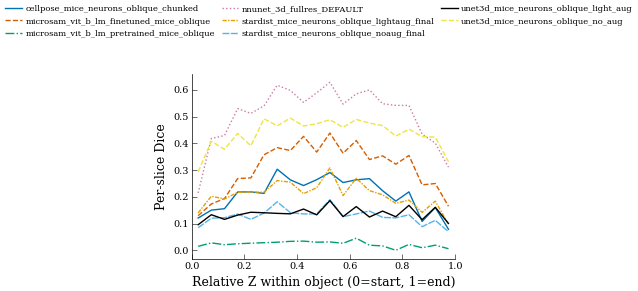

Saved: /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/plots/within_object_dice_vs_zrel.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  9d continued: Z-relative Dice profile plot
# ══════════════════════════════════════════════════════════════════════════════

if not df_obj_z.empty:
    df_obj_z['z_rel_bin'] = pd.cut(df_obj_z['z_rel'], bins=20, labels=False)
    bin_centers = np.linspace(0.025, 0.975, 20)

    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    for i, mn in enumerate(ms):
        md = df_obj_z[df_obj_z['model']==mn]
        g = md.groupby('z_rel_bin')['slice_dice'].mean()
        bins_present = g.index.values
        vals = g.values
        ax.plot(bin_centers[bins_present.astype(int)], vals, label=mn, **_s(i))

    ax.set_xlabel('Relative Z within object (0=start, 1=end)')
    ax.set_ylabel('Per-slice Dice')
    ax.set_xlim(0, 1)
    _cl(ax)
    _leg(fig, ax)
    p = os.path.join(pdir, 'within_object_dice_vs_zrel.png')
    fig.savefig(p, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'Saved: {p}')

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#  9e. Visual audit: FP at edge slices
#
#  Find edge slices where prediction has objects but GT doesn't.
#  Save montage: raw image | GT mask | pred mask
#  Observer can verify if FP corresponds to visible signal.
# ══════════════════════════════════════════════════════════════════════════════

def find_fp_edge_slices(gt, pred, edge_frac=0.15, max_examples=3):
    nz = gt.shape[0]
    boundary = max(1, int(np.ceil(nz * edge_frac)))
    edge_slices = list(range(boundary)) + list(range(nz - boundary, nz))
    examples = []
    for z in edge_slices:
        gt_area = np.sum(gt[z] > 0)
        pred_area = np.sum(pred[z] > 0)
        if pred_area > 50 and gt_area < pred_area * 0.3:
            examples.append((z, int(gt_area), int(pred_area)))
    examples.sort(key=lambda x: x[2] - x[1], reverse=True)
    return examples[:max_examples]

audit_dir = os.path.join(ced, 'visual_audit_fp_edges')
os.makedirs(audit_dir, exist_ok=True)

raw_files = {}
if os.path.isdir(RAW_DIR):
    for f in glob.glob(os.path.join(RAW_DIR, '*.tif')) + glob.glob(os.path.join(RAW_DIR, '*.tiff')):
        raw_files[normalize_filename(f)] = f

audit_log = []
for (mn, vn), (gv, pv) in vol_cache.items():
    examples = find_fp_edge_slices(gv, pv, EDGE_FRACTION, max_examples=3)
    if not examples:
        continue
    raw_key = vn.lower()
    raw_vol = None
    if raw_key in raw_files:
        try:
            raw_vol = tifffile.imread(raw_files[raw_key])
        except:
            pass
    for z, gt_a, pred_a in examples:
        ncols = 3 if raw_vol is not None else 2
        fig, axes = plt.subplots(1, ncols, figsize=(ncols * 2.5, 2.5))
        col = 0
        if raw_vol is not None and z < raw_vol.shape[0]:
            axes[col].imshow(raw_vol[z], cmap='gray')
            axes[col].set_title('Raw', fontsize=7)
            col += 1
        gt_rgb = np.zeros((*gv[z].shape, 3), dtype=np.uint8)
        gt_rgb[gv[z] > 0] = [0, 255, 0]
        axes[col].imshow(gt_rgb)
        axes[col].set_title(f'GT (area={gt_a})', fontsize=7)
        col += 1
        pred_rgb = np.zeros((*pv[z].shape, 3), dtype=np.uint8)
        pred_rgb[pv[z] > 0] = [255, 0, 0]
        axes[col].imshow(pred_rgb)
        axes[col].set_title(f'Pred (area={pred_a})', fontsize=7)
        for a in axes:
            a.axis('off')
        fig.suptitle(f'{mn} / {vn} / z={z}', fontsize=8, y=0.98)
        fig.tight_layout()
        fp = os.path.join(audit_dir, f'{mn}_{vn}_z{z:03d}.png')
        fig.savefig(fp, dpi=150, bbox_inches='tight')
        plt.close(fig)
        audit_log.append(dict(model=mn, volume=vn, z=z, gt_area=gt_a, pred_area=pred_a))

df_audit = pd.DataFrame(audit_log)
if not df_audit.empty:
    df_audit.to_csv(os.path.join(audit_dir, 'audit_log.csv'), index=False)
print(f"Visual audit: {len(audit_log)} FP-at-edge examples saved to {audit_dir}")

Visual audit: 0 FP-at-edge examples saved to /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/visual_audit_fp_edges


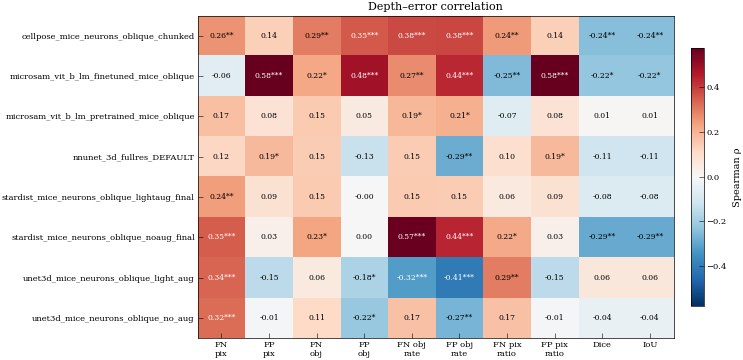

Saved: /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/plots/depth_correlation_heatmap.png


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
#  Correlation heatmap
# ══════════════════════════════════════════════════════════════════════════════

if not df_cr.empty:
    pr_pivot = df_cr.pivot(index='model',columns='metric',values='rho')
    pp_pivot = df_cr.pivot(index='model',columns='metric',values='p')
    co = [c for c in cm if c in pr_pivot.columns]
    pr_pivot, pp_pivot = pr_pivot[co], pp_pivot[co]
    nm,nc = len(pr_pivot.index), len(co)
    fig,ax = plt.subplots(figsize=(max(4,0.65*nc+1.5), max(1.6,0.4*nm+0.6)))
    arr = pr_pivot.values.astype(float)
    vx = max(abs(np.nanmin(arr)),abs(np.nanmax(arr)),0.3)
    im = ax.imshow(arr, cmap='RdBu_r', vmin=-vx, vmax=vx, aspect='auto')
    sh = {'FN_pixels':'FN\npix','FP_pixels':'FP\npix','FN_objects':'FN\nobj','FP_objects':'FP\nobj',
          'FN_object_rate':'FN obj\nrate','FP_object_rate':'FP obj\nrate',
          'FN_pixel_ratio':'FN pix\nratio','FP_pixel_ratio':'FP pix\nratio','Dice':'Dice','IoU':'IoU'}
    ax.set_xticks(range(nc)); ax.set_xticklabels([sh.get(c,c) for c in co], fontsize=6)
    ax.set_yticks(range(nm)); ax.set_yticklabels(pr_pivot.index, fontsize=6)
    for i in range(nm):
        for j in range(nc):
            rv=arr[i,j]; pv=pp_pivot.values[i,j]
            if np.isnan(rv): t='—'
            else:
                s='***' if (not np.isnan(pv) and pv<.001) else ('**' if (not np.isnan(pv) and pv<.01) else ('*' if (not np.isnan(pv) and pv<.05) else ''))
                t=f'{rv:.2f}{s}'
            tc='white' if abs(rv if not np.isnan(rv) else 0)>vx*0.55 else 'black'
            ax.text(j,i,t,ha='center',va='center',fontsize=5.5,color=tc)
    cb=fig.colorbar(im,ax=ax,shrink=0.8,pad=0.03)
    cb.set_label('Spearman ρ',fontsize=7); cb.ax.tick_params(labelsize=6)
    ax.set_title('Depth–error correlation',fontsize=8,pad=4)
    fig.tight_layout()
    hp=os.path.join(pdir,'depth_correlation_heatmap.png')
    fig.savefig(hp,dpi=PLOT_DPI,bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'Saved: {hp}')

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
#  9f. Qualitative failure modes classification
#
#  For each volume, classify every GT and Pred object into failure categories:
#
#    GT-side (what happened to each ground truth object):
#      TP_CLEAN    — matched 1:1, IoU ≥ thresh
#      UNDERSEG    — GT matched but IoU < thresh; pred covers only part
#      MERGED      — multiple GT objects matched to same pred (many:1)
#      MISSED      — GT object has no significant overlap with any pred
#
#    Pred-side (what each predicted object corresponds to):
#      TP_CLEAN    — matched 1:1, IoU ≥ thresh
#      OVERSEG     — pred overlaps single GT but IoU < thresh (pred is a fragment)
#      SPLIT       — multiple pred objects overlap same GT significantly (1:many)
#      SPURIOUS    — pred object has no significant overlap with any GT
#
#  Also detects:
#      BOUNDARY_ERR — matched pair where most error is at z-start/z-end of object
#
#  Outputs:
#    - per-object classification CSV
#    - summary counts per model
#    - worst-case visual examples per failure mode
# ══════════════════════════════════════════════════════════════════════════════


from collections import Counter

def classify_failure_modes_cached(gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols, gt, pred, iou_thresh=0.5):
    ng, np_ = len(gt_ids), len(pred_ids)
    matches = hungarian_match(iou_mat, iou_thresh)
    matched_gt = {m[0]: m for m in matches}
    matched_pr = {m[1]: m for m in matches}

    gt_records = []
    pred_records = []

    # GT-side: which preds overlap each GT significantly?
    gt_overlapping_preds = {}
    for i in range(ng):
        overlaps = []
        for j in range(np_):
            if overlap[i, j] > 0:
                frac = overlap[i, j] / gt_vols[i] if gt_vols[i] > 0 else 0.
                if frac >= OVERLAP_MIN_FRAC:
                    overlaps.append((j, frac, float(iou_mat[i, j])))
        gt_overlapping_preds[i] = overlaps

    # Pred-side: which GTs overlap each pred significantly?
    pred_overlapping_gts = {}
    for j in range(np_):
        overlaps = []
        for i in range(ng):
            if overlap[i, j] > 0:
                frac = overlap[i, j] / pred_vols[j] if pred_vols[j] > 0 else 0.
                if frac >= OVERLAP_MIN_FRAC:
                    overlaps.append((i, frac, float(iou_mat[i, j])))
        pred_overlapping_gts[j] = overlaps

    gt_best_pred = {}
    for i in range(ng):
        if gt_overlapping_preds[i]:
            best = max(gt_overlapping_preds[i], key=lambda x: x[2])
            gt_best_pred[i] = best[0]

    pred_gt_count = Counter(gt_best_pred.values())

    pred_best_gt = {}
    for j in range(np_):
        if pred_overlapping_gts[j]:
            best = max(pred_overlapping_gts[j], key=lambda x: x[2])
            pred_best_gt[j] = best[0]

    gt_pred_count = Counter(pred_best_gt.values())

    # Classify each GT object
    for i in range(ng):
        gid = int(gt_ids[i])
        vol = int(gt_vols[i])
        rec = {'gt_id': gid, 'volume_voxels': vol}

        if i in matched_gt:
            _, pj, iou_val = matched_gt[i]
            rec['matched_pred_id'] = int(pred_ids[pj])
            rec['iou'] = iou_val
            if gt_pred_count.get(i, 0) > 1:
                rec['mode'] = 'SPLIT_TARGET'
                rec['n_pred_fragments'] = gt_pred_count[i]
            else:
                is_boundary = _check_boundary_error(gt, pred, gid, int(pred_ids[pj]))
                if is_boundary:
                    rec['mode'] = 'TP_BOUNDARY_ERR'
                else:
                    rec['mode'] = 'TP_CLEAN'
        else:
            if i in gt_best_pred:
                best_pj = gt_best_pred[i]
                best_iou = iou_mat[i, best_pj]
                if pred_gt_count.get(best_pj, 0) > 1:
                    rec['mode'] = 'MERGED'
                    rec['merged_into_pred'] = int(pred_ids[best_pj])
                    rec['iou'] = float(best_iou)
                else:
                    rec['mode'] = 'UNDERSEG'
                    rec['best_pred_id'] = int(pred_ids[best_pj])
                    rec['iou'] = float(best_iou)
            else:
                rec['mode'] = 'MISSED'
                rec['iou'] = 0.
        gt_records.append(rec)

    # Classify each Pred object
    for j in range(np_):
        pid = int(pred_ids[j])
        vol = int(pred_vols[j])
        rec = {'pred_id': pid, 'volume_voxels': vol}

        if j in matched_pr:
            gi, _, iou_val = matched_pr[j]
            rec['matched_gt_id'] = int(gt_ids[gi])
            rec['iou'] = iou_val
            rec['mode'] = 'TP_CLEAN'
        else:
            if j in pred_best_gt:
                best_gi = pred_best_gt[j]
                best_iou = iou_mat[best_gi, j]
                if gt_pred_count.get(best_gi, 0) > 1:
                    rec['mode'] = 'OVERSEG'
                    rec['parent_gt_id'] = int(gt_ids[best_gi])
                    rec['iou'] = float(best_iou)
                else:
                    rec['mode'] = 'SPLIT'
                    rec['overlaps_gt_id'] = int(gt_ids[best_gi])
                    rec['iou'] = float(best_iou)
            else:
                rec['mode'] = 'SPURIOUS'
                rec['iou'] = 0.
        pred_records.append(rec)

    return gt_records, pred_records


def _check_boundary_error(gt, pred, gt_id, pred_id):
    z_present = np.where(np.any(gt == gt_id, axis=(1, 2)))[0]
    if len(z_present) < 5:
        return False
    z_start, z_end = z_present[0], z_present[-1]
    z_span = z_end - z_start + 1
    boundary_depth = max(1, int(np.ceil(z_span * 0.2)))

    # Only check boundary slices instead of full volume scan
    fn_total = 0
    fn_boundary = 0
    for z in z_present:
        gt_slice = (gt[z] == gt_id)
        pred_slice = (pred[z] == pred_id)
        fn_slice = int(np.sum(gt_slice & ~pred_slice))
        fn_total += fn_slice
        if (z - z_start) < boundary_depth or (z_end - z) < boundary_depth:
            fn_boundary += fn_slice

    if fn_total == 0:
        return False
    return (fn_boundary / fn_total) >= BOUNDARY_ERR_FRAC


print("Classifying failure modes...\n")
all_gt_class = []
all_pred_class = []

for (mn, vn), (gv, pv) in vol_cache.items():
    print(f"  {mn}/{vn}", end=" ", flush=True)
    gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols = iou_cache[(mn, vn)]
    gt_recs, pred_recs = classify_failure_modes_cached(
        gt_ids, pred_ids, iou_mat, overlap, gt_vols, pred_vols, gv, pv, IOU_THRESH)
    for r in gt_recs:
        r['model'] = mn; r['volume'] = vn
    for r in pred_recs:
        r['model'] = mn; r['volume'] = vn
    all_gt_class.extend(gt_recs)
    all_pred_class.extend(pred_recs)
    gt_modes = Counter(r['mode'] for r in gt_recs)
    pred_modes = Counter(r['mode'] for r in pred_recs)
    print(f"GT: {dict(gt_modes)}  Pred: {dict(pred_modes)}")

df_gt_class = pd.DataFrame(all_gt_class)
df_pred_class = pd.DataFrame(all_pred_class)
df_gt_class.to_csv(os.path.join(ced, 'failure_modes_gt.csv'), index=False)
df_pred_class.to_csv(os.path.join(ced, 'failure_modes_pred.csv'), index=False)

Classifying failure modes...

  cellpose_mice_neurons_oblique_chunked/20260209_161350 GT: {'UNDERSEG': 14, 'TP_BOUNDARY_ERR': 1, 'MISSED': 15, 'SPLIT_TARGET': 1}  Pred: {'TP_CLEAN': 2, 'SPLIT': 13, 'OVERSEG': 24}
  cellpose_mice_neurons_oblique_chunked/mouse_obl_14 GT: {'TP_BOUNDARY_ERR': 9, 'TP_CLEAN': 3, 'UNDERSEG': 19, 'SPLIT_TARGET': 1, 'MISSED': 8}  Pred: {'TP_CLEAN': 13, 'OVERSEG': 42, 'SPURIOUS': 9, 'SPLIT': 7}
  cellpose_mice_neurons_oblique_chunked/mouse_obl_15 GT: {'TP_BOUNDARY_ERR': 4, 'UNDERSEG': 13, 'TP_CLEAN': 4, 'MISSED': 3, 'SPLIT_TARGET': 2}  Pred: {'TP_CLEAN': 10, 'SPURIOUS': 16, 'OVERSEG': 27, 'SPLIT': 5}
  cellpose_mice_neurons_oblique_chunked/mouse_obl_6 GT: {'TP_CLEAN': 5, 'UNDERSEG': 8, 'SPLIT_TARGET': 2, 'TP_BOUNDARY_ERR': 4}  Pred: {'TP_CLEAN': 11, 'SPLIT': 6, 'OVERSEG': 8, 'SPURIOUS': 8}
  microsam_vit_b_lm_finetuned_mice_oblique/20260209_161350 GT: {'TP_BOUNDARY_ERR': 5, 'TP_CLEAN': 3, 'UNDERSEG': 14, 'MISSED': 7, 'MERGED': 2}  Pred: {'OVERSEG': 6, 'TP_CLEAN'

FAILURE MODE SUMMARY — GT objects

cellpose_mice_neurons_oblique_chunked (n=116):
  TP_CLEAN                12  ( 10.3%)  █████
  TP_BOUNDARY_ERR         18  ( 15.5%)  ███████
  SPLIT_TARGET             6  (  5.2%)  ██
  UNDERSEG                54  ( 46.6%)  ███████████████████████
  MERGED                   0  (  0.0%)  
  MISSED                  26  ( 22.4%)  ███████████

microsam_vit_b_lm_finetuned_mice_oblique (n=116):
  TP_CLEAN                11  (  9.5%)  ████
  TP_BOUNDARY_ERR         35  ( 30.2%)  ███████████████
  SPLIT_TARGET             2  (  1.7%)  
  UNDERSEG                33  ( 28.4%)  ██████████████
  MERGED                  20  ( 17.2%)  ████████
  MISSED                  15  ( 12.9%)  ██████

microsam_vit_b_lm_pretrained_mice_oblique (n=116):
  TP_CLEAN                 2  (  1.7%)  
  TP_BOUNDARY_ERR          2  (  1.7%)  
  SPLIT_TARGET             0  (  0.0%)  
  UNDERSEG                63  ( 54.3%)  ███████████████████████████
  MERGED                   8  (  6.9%

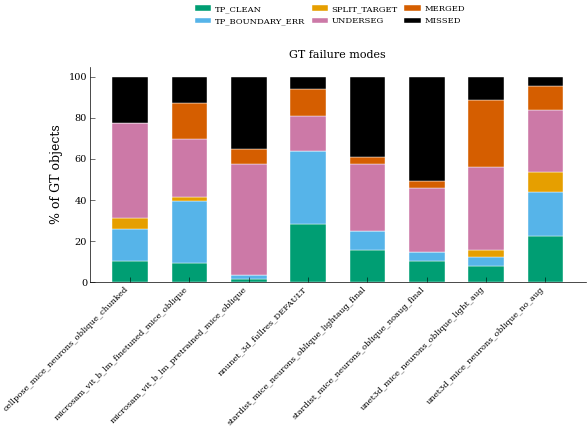

Saved: /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/plots/failure_modes_gt_stacked.png


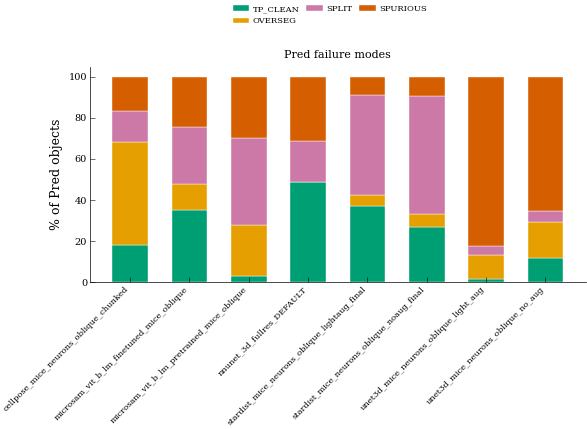

Saved: /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/plots/failure_modes_pred_stacked.png


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
#  9f continued: summary table + stacked bar plot
# ══════════════════════════════════════════════════════════════════════════════

GT_MODES = ['TP_CLEAN', 'TP_BOUNDARY_ERR', 'SPLIT_TARGET', 'UNDERSEG', 'MERGED', 'MISSED']
PRED_MODES = ['TP_CLEAN', 'OVERSEG', 'SPLIT', 'SPURIOUS']

MODE_COLORS_GT = {
    'TP_CLEAN': '#009E73', 'TP_BOUNDARY_ERR': '#56B4E9',
    'SPLIT_TARGET': '#E69F00', 'UNDERSEG': '#CC79A7',
    'MERGED': '#D55E00', 'MISSED': '#000000',
}
MODE_COLORS_PRED = {
    'TP_CLEAN': '#009E73', 'OVERSEG': '#E69F00',
    'SPLIT': '#CC79A7', 'SPURIOUS': '#D55E00',
}

print("=" * 70)
print("FAILURE MODE SUMMARY — GT objects")
print("=" * 70)

gt_summary_rows = []
for mn in ms:
    md = df_gt_class[df_gt_class['model'] == mn]
    total = len(md)
    if total == 0: continue
    row = {'model': mn, 'total_gt': total}
    print(f"\n{mn} (n={total}):")
    for mode in GT_MODES:
        n = len(md[md['mode'] == mode])
        pct = 100 * n / total
        row[mode] = n
        row[f'{mode}_%'] = pct
        bar = '█' * int(pct / 2)
        print(f"  {mode:20s}  {n:4d}  ({pct:5.1f}%)  {bar}")
    gt_summary_rows.append(row)

df_gt_summary = pd.DataFrame(gt_summary_rows)
df_gt_summary.to_csv(os.path.join(ced, 'failure_modes_gt_summary.csv'), index=False)

print("\n" + "=" * 70)
print("FAILURE MODE SUMMARY — Pred objects")
print("=" * 70)

pred_summary_rows = []
for mn in ms:
    md = df_pred_class[df_pred_class['model'] == mn]
    total = len(md)
    if total == 0: continue
    row = {'model': mn, 'total_pred': total}
    print(f"\n{mn} (n={total}):")
    for mode in PRED_MODES:
        n = len(md[md['mode'] == mode])
        pct = 100 * n / total
        row[mode] = n
        row[f'{mode}_%'] = pct
        bar = '█' * int(pct / 2)
        print(f"  {mode:20s}  {n:4d}  ({pct:5.1f}%)  {bar}")
    pred_summary_rows.append(row)

df_pred_summary = pd.DataFrame(pred_summary_rows)
df_pred_summary.to_csv(os.path.join(ced, 'failure_modes_pred_summary.csv'), index=False)

def _stacked_bar(df_summary, modes, colors, title, ylabel, path):
    if df_summary.empty: return
    fig, ax = plt.subplots(figsize=(max(3.0, 0.8 * len(ms)), 2.8))
    models_list = df_summary['model'].values
    x = np.arange(len(models_list))
    width = 0.6
    bottom = np.zeros(len(models_list))
    total_key = 'total_gt' if 'total_gt' in df_summary.columns else 'total_pred'
    totals = df_summary[total_key].values.astype(float)
    for mode in modes:
        if mode not in df_summary.columns: continue
        vals = df_summary[mode].values.astype(float)
        pcts = 100 * vals / np.where(totals > 0, totals, 1)
        ax.bar(x, pcts, width, bottom=bottom, label=mode,
               color=colors.get(mode, '#999999'), edgecolor='white', linewidth=0.3)
        bottom += pcts
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=45, ha='right', fontsize=6)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=8, pad=6)
    ax.set_ylim(0, 105)
    _cl(ax); _leg(fig, ax)
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f"Saved: {path}")

_stacked_bar(df_gt_summary, GT_MODES, MODE_COLORS_GT,
             'GT failure modes', '% of GT objects',
             os.path.join(pdir, 'failure_modes_gt_stacked.png'))

_stacked_bar(df_pred_summary, PRED_MODES, MODE_COLORS_PRED,
             'Pred failure modes', '% of Pred objects',
             os.path.join(pdir, 'failure_modes_pred_stacked.png'))

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
#  9f continued: worst-case visual examples per failure mode
#
#  For each model × failure mode, find the most egregious examples and
#  render mid-slice montage: GT mask (green) | Pred mask (red) | overlay
# ══════════════════════════════════════════════════════════════════════════════

fail_vis_dir = os.path.join(ced, 'failure_mode_examples')
os.makedirs(fail_vis_dir, exist_ok=True)

def _get_object_midslice(vol, obj_id):
    z_present = np.where(np.any(vol == obj_id, axis=(1, 2)))[0]
    if len(z_present) == 0: return None
    return z_present[len(z_present) // 2]

def _render_failure_example(gt, pred, obj_id, is_gt_side, z, title, path):
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    gt_z = gt[z]
    pred_z = pred[z]

    gt_rgb = np.zeros((*gt_z.shape, 3), dtype=np.uint8)
    gt_rgb[gt_z > 0] = [80, 80, 80]
    if is_gt_side:
        gt_rgb[gt_z == obj_id] = [0, 255, 0]
    axes[0].imshow(gt_rgb); axes[0].set_title('GT', fontsize=7)

    pred_rgb = np.zeros((*pred_z.shape, 3), dtype=np.uint8)
    pred_rgb[pred_z > 0] = [80, 80, 80]
    if not is_gt_side:
        pred_rgb[pred_z == obj_id] = [255, 0, 0]
    else:
        gt_mask = (gt_z == obj_id)
        overlapping_preds = np.unique(pred_z[gt_mask])
        for pid in overlapping_preds:
            if pid > 0:
                pred_rgb[pred_z == pid] = [255, 0, 0]
    axes[1].imshow(pred_rgb); axes[1].set_title('Pred', fontsize=7)

    overlay = np.zeros((*gt_z.shape, 3), dtype=np.uint8)
    if is_gt_side:
        overlay[gt_z == obj_id, 1] = 200
        gt_mask = (gt_z == obj_id)
        overlapping_preds = np.unique(pred_z[gt_mask])
        for pid in overlapping_preds:
            if pid > 0:
                overlay[pred_z == pid, 0] = 200
    else:
        overlay[pred_z == obj_id, 0] = 200
        pred_mask = (pred_z == obj_id)
        overlapping_gts = np.unique(gt_z[pred_mask])
        for gid in overlapping_gts:
            if gid > 0:
                overlay[gt_z == gid, 1] = 200
    axes[2].imshow(overlay); axes[2].set_title('Overlay', fontsize=7)

    for a in axes: a.axis('off')
    fig.suptitle(title, fontsize=7, y=0.99)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)

n_saved = 0
for mn in ms:
    for mode in ['MISSED', 'MERGED', 'UNDERSEG', 'TP_BOUNDARY_ERR']:
        subset = df_gt_class[(df_gt_class['model'] == mn) & (df_gt_class['mode'] == mode)]
        if subset.empty: continue
        if mode == 'MISSED':
            subset = subset.sort_values('volume_voxels', ascending=False)
        else:
            subset = subset.sort_values('iou', ascending=True)
        for idx, (_, row) in enumerate(subset.head(N_WORST_EXAMPLES).iterrows()):
            key = (mn, row['volume'])
            if key not in vol_cache: continue
            gv, pv = vol_cache[key]
            gid = int(row['gt_id'])
            z = _get_object_midslice(gv, gid)
            if z is None: continue
            title = (f"{mn} / {row['volume']} / z={z} | GT#{gid} | "
                     f"{mode} | vol={row['volume_voxels']}")
            fp = os.path.join(fail_vis_dir,
                              f"GT_{mode}_{mn}_{row['volume']}_id{gid}.png")
            _render_failure_example(gv, pv, gid, True, z, title, fp)
            n_saved += 1

    for mode in ['SPURIOUS', 'OVERSEG']:
        subset = df_pred_class[(df_pred_class['model'] == mn) & (df_pred_class['mode'] == mode)]
        if subset.empty: continue
        subset = subset.sort_values('volume_voxels', ascending=False)
        for idx, (_, row) in enumerate(subset.head(N_WORST_EXAMPLES).iterrows()):
            key = (mn, row['volume'])
            if key not in vol_cache: continue
            gv, pv = vol_cache[key]
            pid = int(row['pred_id'])
            z = _get_object_midslice(pv, pid)
            if z is None: continue
            title = (f"{mn} / {row['volume']} / z={z} | Pred#{pid} | "
                     f"{mode} | vol={row['volume_voxels']}")
            fp = os.path.join(fail_vis_dir,
                              f"PRED_{mode}_{mn}_{row['volume']}_id{pid}.png")
            _render_failure_example(gv, pv, pid, False, z, title, fp)
            n_saved += 1

print(f"\nFailure mode examples: {n_saved} images saved to {fail_vis_dir}")


Failure mode examples: 137 images saved to /NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/results/evaluation/failure_mode_examples


## 10 — Final

In [29]:
print('='*80)
print('FINAL RESULTS')
print('='*80)
for mn,g in df_vol.groupby('model'):
    print(f"\n{mn} (n={len(g)}):")
    for c in pcols:
        v=g[c].values*100
        print(f"  {c:25s}  {np.mean(v):6.2f} ± {np.std(v):5.2f}")
print(f"\nAll saved to: {ced}")

FINAL RESULTS

cellpose_mice_neurons_oblique_chunked (n=4):
  AJI                         35.30 ±  9.68
  Obj_F1@0.5                  23.81 ± 12.94
  Obj_Prec@0.5                18.50 ± 10.01
  Obj_Rec@0.5                 33.83 ± 18.38
  Obj_IoU@0.5                 20.71 ± 11.31
  mAP_0.5_0.95                 9.26 ±  5.03
  Pixel_Dice                  56.31 ± 10.01
  Pixel_IoU                   39.83 ±  9.26
  Pixel_Prec                  82.88 ±  5.68
  Pixel_Rec                   44.12 ± 11.21

microsam_vit_b_lm_finetuned_mice_oblique (n=4):
  AJI                         36.48 ±  4.02
  Obj_F1@0.5                  39.93 ± 12.76
  Obj_Prec@0.5                36.58 ± 10.78
  Obj_Rec@0.5                 44.13 ± 15.38
  Obj_IoU@0.5                 26.44 ±  9.36
  mAP_0.5_0.95                11.26 ±  4.34
  Pixel_Dice                  60.39 ±  5.06
  Pixel_IoU                   43.44 ±  5.08
  Pixel_Prec                  55.68 ±  2.91
  Pixel_Rec                   67.50 ± 11.45

microsam_v